In [1]:


# importing
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
import netCDF4
from netCDF4 import Dataset
import math
from cartopy.util import add_cyclic_point
from sklearn import linear_model as lm
import statsmodels.formula.api as stm
import statsmodels.api as sm
from sklearn.metrics import r2_score
from numpy import genfromtxt
import rioxarray
from sklearn.linear_model import TheilSenRegressor
from scipy.ndimage import gaussian_filter1d
import requests
import itertools
from scipy.stats import linregress

from datetime import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors
from matplotlib.gridspec import GridSpec
import seaborn as sns
#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from rasterio import features
from affine import Affine
import geopandas as gp

plt.rcParams['hatch.linewidth'] = 1.5
plt.rcParams['hatch.color'] = 'k'
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.sans-serif'] = "Arial"
mpl.rcParams['font.size'] = "16"
from matplotlib import rcParams
rcParams["mathtext.default"] = "regular"

import warnings
warnings.filterwarnings(action='ignore')

/dartfs-hpc/rc/home/q/f006fqq/.conda/envs/cl1020/lib/python3.8/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex


In [2]:
cm2mm=10
pthresh = 5 #mm/day


In [3]:
#data dirs
grace_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GRACE/'
gini_dir = 'dartfs-hpc/rc/lab/C/CMIG/clesk/projects/plcl/data/hydro-gini/'
cpc_dir =  '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/CPC/ppt/'
save_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/'
fig_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/figs/'

### core functions

In [5]:
def gini(x):
    # computes unweighted gini index on a vector
    # from: https://stackoverflow.com/questions/39512260/calculating-gini-coefficient-in-python-numpy
    # equivalent to (np.sum((2 * index - n  - 1) * x)) / (n * np.sum(x)), which is more common notation but slower
    
    n = len(x)
    
    # if obs missing, drop
    x[np.isnan(x)] = np.median(x)
    
    cumx = np.cumsum(x, dtype=float)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

In [10]:
pr_gini = xr.open_dataset('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/CPC_daily_pr_gini_water_year_2002-2022.nc')


In [560]:
###################################################################################################################
###################################################################################################################
##### THIS IS THE SEBM FROM "THE PHYSICS OF HEAT WAVES" PAPER #####################################################
##### First function calculates saturation vapor pressure assuming constant surface pressure ######################
##### Second function accepts radiation and precipitation forcing and returns temperature and soil moisture #######
###################################################################################################################
###################################################################################################################


def q_s(TK): 					# ACCEPTS TEMPERAUTRE IN KELVIN
	T = TK - 273.15 			# Now in Celsius
	e_s = 6.11*10**(7.5*T/(237.5+T)) 	# Formula @ https://www.weather.gov/media/epz/wxcalc/vaporPressure.pdf
	q_s = 0.61*e_s/1013			# Converting to kg/kg
	return(q_s) # Given in units of kg H2O/ kg air

def the_model(F_forcing,P_forcing):

	########### F forcing is W/m^2
	########### P forcing is in mm per unit of time

	############# Climatological constants #####################################

	q_clim = 0.005 			# kg/kg 
	TD_clim = 280			# K
	DT = 86400			# in seconds (appropriate for daily forcing)

	########### Tunable parameters #################################################

	r_s = 100			# s/m
	v_H = 10			# W/m^2/K

############ Geometry

	h_s = 1			# surface layer depth [m]
	theta_max = 0.4656		# porosity
	N = len(F_forcing)
	
############### Physical Constants

	rho_l = 1000			# denisty of water [kg/m^3]
	rho_s = 1000			# density of dry soil [kg/m^3]
	rho_a = 1.25			# density of air [kg/m^3]
	c_ps  = 1000			# heat capacity of dry soil [J/kg/K]
	L = 2257000			# Latent enthalpy of vaporization [J/kg]

################### Combined parameters

	mu_s = rho_l*h_s*theta_max	# storage capacity of surface layer [kg/m^2]
	C_s = rho_s*h_s*c_ps		# effective heat capacity of land surface [J/m^2/K]

################# State Variables

	T = np.zeros(N)
	m_s = np.zeros(N)
	m_d = np.zeros(N)
	LHF = np.zeros(N)

	T[0] = 280			# Initial condition for surface temperature
	m_s[0] = 0.6			# ""			surface moisture

	i = 0
	while i < N-1:
		
		######### CALCULATING FLUXES #####################################
			
		H = v_H*(T[i] - TD_clim)		# Sensible Heat Flux [W/m^2]
		VPD = q_s(T[i]) - q_clim		# Vapor Pressure Deficit [kPa]

		if VPD > 0 and T[i] > 273.15:
			ET = rho_a*m_s[i]*VPD/r_s	# Surface Evaporation [kg/m^2/s]
		else:
			ET = 0

		LHF[i] = L*ET

		########## TENDENCY EQUATIONS #####################################

		dT_dt = (F_forcing[i] - H - LHF[i])/C_s
		dms_dt = -(ET/mu_s)

		############# INTEGRATING FORWARD IN TIME #########################

		T[i+1] 		= T[i] + dT_dt*DT
		m_s[i+1]	= m_s[i] + dms_dt*DT + P_forcing[i]/(mu_s)

		############# If bucket overfills, we take the moisture out #######

		if m_s[i+1] > 1:
			m_s[i+1] = 1

		if m_s[i+1] < 0:
			m_s[i+1] = 0
		i+=1

	return(T,m_s,LHF)

# SEMB model with surface reservoir

### plot key parameterizations

Text(0, 0.5, 'daily Q (mm)')

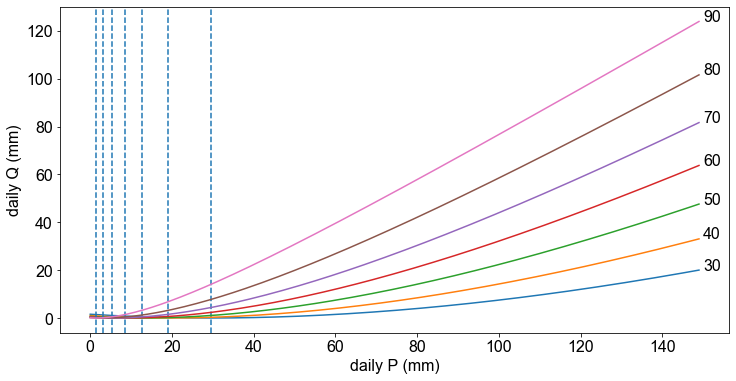

In [10]:
# US SCS runoff scheme
for CN in np.arange(30,91,10):
    P = np.arange(0,150)
    S = 25.4*(1000/CN - 10)
    I = 0.05*S

    Q = (P-I)**2 / (P-I+S)

    plt.plot(P,Q)
    plt.axvline(I,linestyle='--')
    plt.text(150,Q[-1],str(CN))

plt.xlabel('daily P (mm)')
plt.ylabel('daily Q (mm)')


Text(0.5, 0, 'm [m3/m3]')

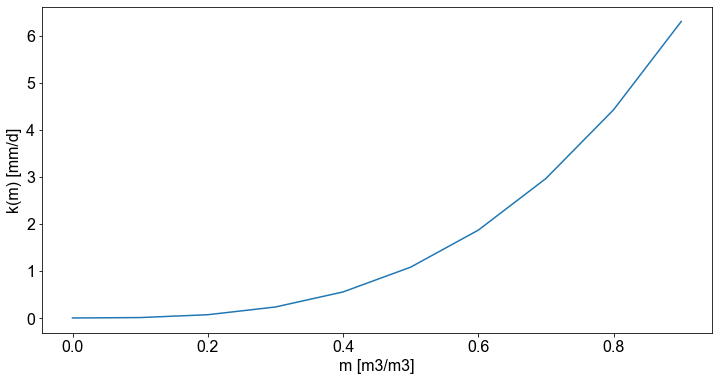

In [11]:
# unsaturated hydraulic conductivity scheme
ks=0.0001
c = 12.8
s=np.arange(0,1,0.1)
k = ks*s**3

plt.plot(s,k*86400)
plt.ylabel('k(m) [mm/d]')
plt.xlabel('m [m3/m3]')


Text(0.5, 0, 'surface reservoir saturation')

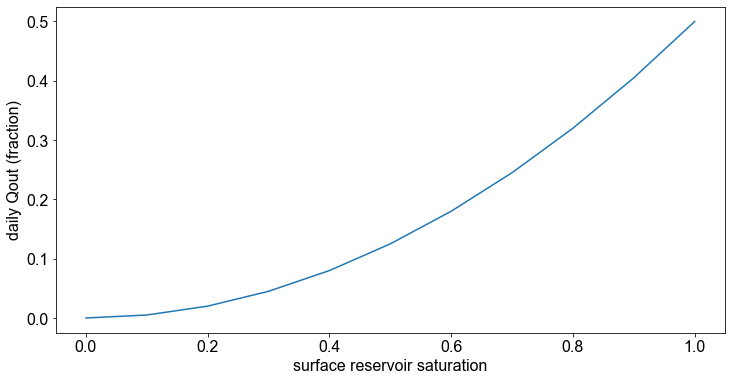

In [12]:
# outflow
thetal = np.arange(0,1.1,0.1)
q = 0.005*thetal**2
plt.plot(thetal,q*0.1*10*100)
plt.ylabel('daily Qout (fraction)')
plt.xlabel('surface reservoir saturation')

### model code

In [7]:
###################################################################################################################
###################################################################################################################
##### Modified from Zeppetello et al. 2022 Jclim -- https://github.com/vargaszeppetello/SEBM ######################
##### First function calculates saturation vapor pressure assuming constant surface pressure ######################
##### Second function accepts radiation and precipitation forcing and returns temperature and soil moisture #######
##### Extension by Lesk et al. : add surface water reservoir, so runoff doesn't disappear from model ##############
###################################################################################################################
###################################################################################################################


def q_s(TK): 					# ACCEPTS TEMPERAUTRE IN KELVIN
	T = TK - 273.15 			# Now in Celsius
	e_s = 6.11*10**(7.5*T/(237.5+T)) 	# Formula @ https://www.weather.gov/media/epz/wxcalc/vaporPressure.pdf
	q_s = 0.61*e_s/1013			# Converting to kg/kg
	return(q_s) # Given in units of kg H2O/ kg air

def the_model_Q(F_forcing,P_forcing,params):

	########### F forcing is W/m^2
	########### P forcing is in mm per unit of time

	############# Climatological constants #####################################

    q_clim = params['q_clim'] 			# kg/kg 
    TD_clim = params['TD_clim']		# K
    DT = 86400			# in seconds (appropriate for daily forcing)

	########### Tunable parameters #################################################

    r_s = params['r_s']			# s/m
    r_lake = params['r_l']
    v_H = params['v_H']			# W/m^2/K
    outflow_rate = params['outflow_rate'] #fraction per day
    c = params['c']          # exponent relating saturated to unsaturated hydraulic conductivity
    Lambda = params['Lambda']     # ratio of initial abstraction to potential maximum soil water retention
    CN = params['CN']        # curve number
    
############ Geometry

    h_s = params['h_s']			# surface layer depth [m]
    h_lake = params['h_l']  # surface reservoir depth [m]
    theta_max = params['theta_max']		# porosity
    N = len(F_forcing)
    a_s = params['a_s']  #fractional area soil
    a_l = params['a_l']  #fractional area surface water
    
############### Physical Constants
    
    ksat = params['ks']            # soil saturated hydraulic conductivity [mm/s]
    rho_l = 1000			# denisty of water [kg/m^3]
    rho_s = 1000			# density of dry soil [kg/m^3]
    rho_a = 1.25			# density of air [kg/m^3]
    c_ps  = 1000			# heat capacity of dry soil [J/kg/K]
    L = 2257000			# Latent enthalpy of vaporization [J/kg]
   
    
################### Combined parameters

    mu_s = rho_l*h_s*theta_max	# storage capacity of surface layer [kg/m^2]
    C_s = rho_s*h_s*c_ps		# effective heat capacity of land surface [J/m^2/K]
    S = 25.4*(1000/CN - 10)       # potential max soil water retention (mm -- trans
    I = Lambda*S             # initial abstraction
    
################# State Variables

    T = np.zeros(N)
    m_s = np.zeros(N)
    m_d = np.zeros(N)
    lake = np.zeros(N)
    LHF = np.zeros(N)
    ET_lake = np.zeros(N)
    ET_land = np.zeros(N)
    Qtotal = np.zeros(N)
    Qoutl = np.zeros(N)

    T[0] = 280			# Initial condition for surface temperature
    m_s[0] = params['m_s0']			# ""			surface moisture
    lake[0] = params['m_l0']
    
    i = 0
    while i < N-1:
		
        ######### time dependend paramters ###############################
        k = ksat*m_s[i]**c
        
		######### CALCULATING FLUXES #####################################
			
        H = v_H*(T[i] - TD_clim)		# Sensible Heat Flux [W/m^2]
        VPD = q_s(T[i]) - q_clim		# Vapor Pressure Deficit [kPa]

        if VPD > 0 and T[i] > 273.15:
            ET = rho_a*m_s[i]*VPD/r_s	# Surface Evaporation [kg/m^2/s]
            ETlake = rho_a*lake[i]*VPD/r_lake
        else:
            ET = 0
            ETlake = 0

        ET_land[i] = DT*ET
        ET_lake[i] = DT*ETlake
        # LHF[i] = L*ET ### small-lake approximation for land-controled evaporation over water
        LHF[i] = L*(a_s*ET+a_l*ETlake) ### energy budget closure

        #drainage
        Qdrain = k #mm/s
        
        #surface runoff
        if P_forcing[i] > I:
            Qinfl = (P_forcing[i]-I)**2 / (P_forcing[i]-I+S) #mm/d
        else:
            Qinfl = 0
        
        #precip - infiltration excess
        Pnet = P_forcing[i] - Qinfl
        
        #lake outflow
       # if lake[i] > 0.5:
        Qout = outflow_rate*lake[i]**2
       # else:
       #     Qout = 0
            
        # saturation excess runoff
       # Qsat = 0 # unless m_s > 1, below
        
		########## TENDENCY EQUATIONS #####################################

        dT_dt = (F_forcing[i] - H - LHF[i])/C_s
        dms_dt = -((ET + Qdrain)/mu_s)        
        
		############# INTEGRATING FORWARD IN TIME #########################

        T[i+1] 		= T[i] + dT_dt*DT
        m_s[i+1]	= m_s[i] + dms_dt*DT + Pnet/mu_s #corrected P term units
        
		############# SATURATION CONSTRAINTS #######

        if m_s[i+1] > 1:
            #Qsat = (m_s[i+1]-1)*mu_s
            m_s[i+1] = 1
            
        elif m_s[i+1] < 0:
            m_s[i+1] = 0
        
        ############ FINALLY, INTEGRATE SURFACE RESERVOIR ############
        dl_dt = (Qdrain*DT + Qinfl)*a_s / (a_l * rho_l * h_lake)
        lake[i+1] = lake[i] + dl_dt + P_forcing[i]/(rho_l*h_lake) - Qout - ETlake*DT/(rho_l * h_lake)
        Qoutl[i] = Qout*rho_l*h_lake*a_l
        Qtotal[i] = (Qdrain*DT + Qinfl)

        i+=1

    return(T,m_s,lake,ET_land,ET_lake,Qtotal,Qoutl)

### run model at a point

In [25]:
#cpc = xr.open_mfdataset(cpc_dir + '*.nc')

#load SRB and select surface all-sky downwelling shortwave
srb_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/GEWEX-SRB/'
srb_ds = xr.open_mfdataset(srb_dir + 'GEWEXSRB_Rel4-IP_Shortwave_daily_local*.nc4')
sw = srb_ds.all_sw_dn_sfc

#resample precip and gini data to SRB resolution
cpc_rs = cpc.interp_like(sw.sel(time=sw.time[0]))
pr_gini_wy = pr_gini.interp_like(sw.sel(time=sw.time[0]))

In [13]:
# set parameter values
def default_params():

    params = {# geometry
              'a_s':0.9,
              'a_l':0.1,
              'h_s':1,
              'h_l':10,
              'theta_max':0.5,

              # climatology
              'q_clim':0.005,
              'TD_clim':280,

              # initial conditions
              'm_s0':0.5,
              'm_l0':0.5,

              # tunable parameters
              'r_s':150,			# s/m
              'r_l':50,
              'v_H':10,			# W/m^2/K
              'ks':1e-4,
              'outflow_rate':0.005, #fraction per day
              'c':12.8,          # exponent relating saturated to unsaturated hydraulic conductivity
              'Lambda':0.05,     # ratio of initial abstraction to potential maximum soil water retention
              'CN':80       # curve number
             }

    return params

In [14]:
# experimental setup: for given point, select max and min gp years and grab the corresponding forcings

def hiLoGpForcing(lon,lat):
    
    #convert point for native CPC resolution
    #lnc = np.floor(s[1])+0.5
    #ltc = np.floor(s[0])+0.5
    
    #get max and min Gp years
    gpsub = pr_gini_wy.sel(lon=lon,lat=lat,water_year=np.arange(2002,2017))
  
    min_year = gpsub['water_year'].isel(water_year=gpsub['Pgini_wy'].argmin(dim='water_year')).values
    max_year = gpsub['water_year'].isel(water_year=gpsub['Pgini_wy'].argmax(dim='water_year')).values
    
    #select P forcings for those years
    p_forcing = cpc_rs.sel(time=slice(f'{min_year-1}-10-01', f'{min_year}-09-30'),lon=lon,lat=lat).precip.compute().values
    p_int = cpc_rs.sel(time=slice(f'{max_year-1}-10-01', f'{max_year}-09-30'),lon=lon,lat=lat).precip

    # ratio of total precip, hi:lo Gp years
    dP = p_int.sum()/p_forcing.sum()

    #scale more intense year to have same total precip
    p_int = (p_int/dP).compute().values

    #select sw forcings
    sw_forcing = sw.sel(time=slice(f'{min_year-1}-10-01', f'{min_year}-09-30'),lon=lon,lat=lat).compute().values
    sw_int = sw.sel(time=slice(f'{max_year-1}-10-01', f'{max_year}-09-30'),lon=lon,lat=lat).compute().values
    
    # difference in dry days and shortwave (just for interpretation)
    dN = sum(p_int<0.1) - sum(p_forcing<0.1)
    dSW = sw_int.mean() - sw_forcing.mean()
    
    return p_forcing,p_int,sw_forcing,sw_int,dN,dSW,min_year,max_year

def calcTWS(SM,L):
    
   #return (params['h_s']*params['a_s'])/(params['h_s']*params['a_s'] + params['h_l']*params['a_l'])*(SM*params['theta_max']*1000) + (params['h_l']*params['a_l'])/(params['h_s']*params['a_s'] + params['h_l']*params['a_l'])*(L*1000)
   return 1000*(params['h_s']*params['a_s']*params['theta_max']*SM + params['h_l']*params['a_l']*L)#/(params['a_l']+params['a_s'])

In [15]:
# test Sample point
lon = 280.5
lat = 37.5

p_forcing,p_int,sw_forcing,sw_int,dN,dSW,minyr,maxyr = hiLoGpForcing(lon,lat)

In [16]:
# set params
params = default_params()

#model runs
#low gp year
T,SM,L,ETland,ETlake,Q,Qout = the_model_Q(sw_forcing,p_forcing,params)
#high gp year
T_int,SM_int,L_int,ETland_int,ETlake_int,Q_int,Qout_int = the_model_Q(sw_int,p_int,params)


#calculate TWS based on soil and lake fractional volume
TWS = calcTWS(SM,L)
TWS_int = calcTWS(SM_int,L_int)
dETland = ETland_int.sum() - ETland.sum()
dETlake = ETlake_int.sum() - ETlake.sum()
dQin = Q_int.sum() - Q.sum()
dQout = Qout_int.sum() - Qout.sum() 


### plot sample point full model output

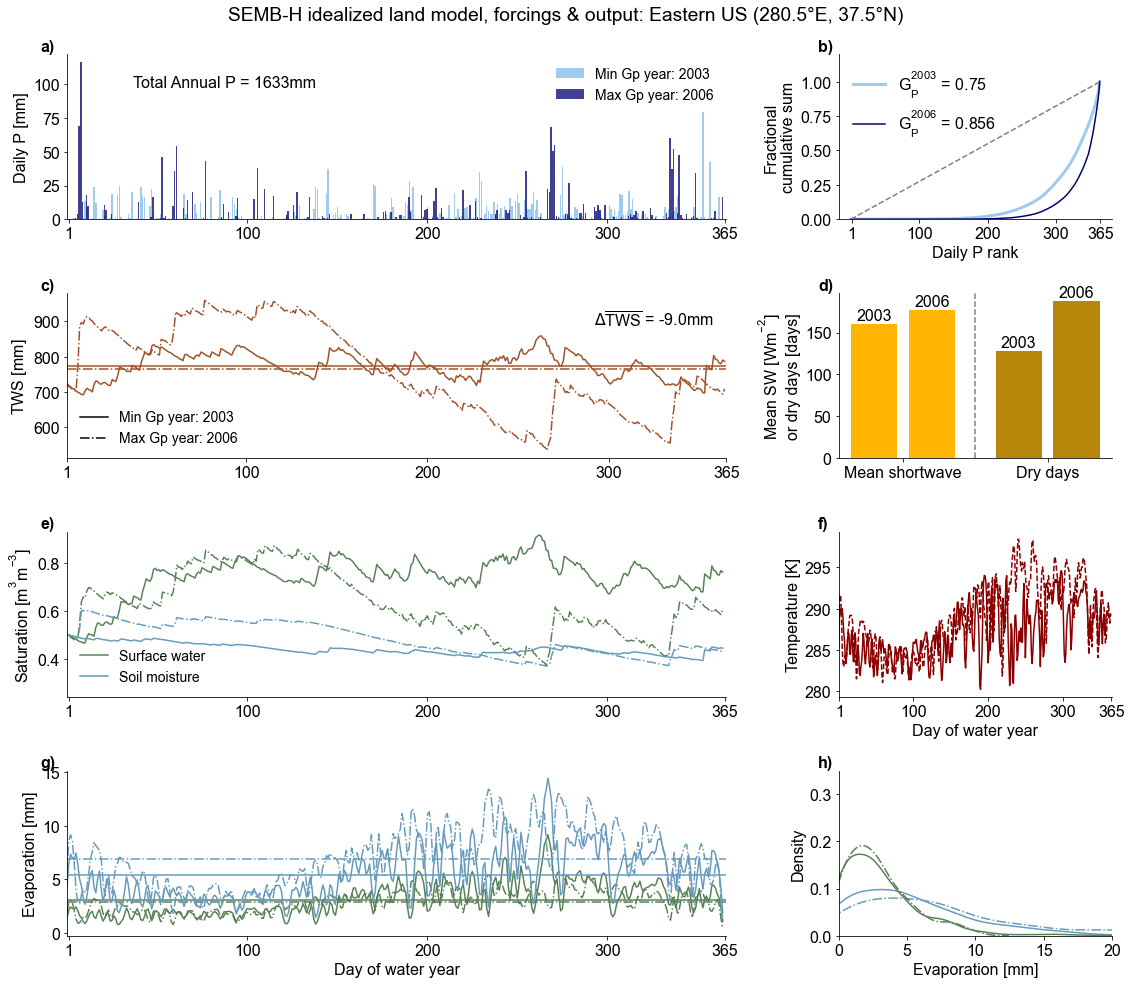

In [19]:
# plot a full control panel of model results:
col_max = '#01016f'
col_min = '#9fcbee'
col_land = '#588157'
col_lake = '#669bbc'

fig = plt.figure(figsize=(16,14))
axs = []
gs = GridSpec(4, 6)

axs.append(fig.add_subplot(gs[0,:4]))
axs.append(fig.add_subplot(gs[0,4:]))
axs.append(fig.add_subplot(gs[1,:4]))
axs.append(fig.add_subplot(gs[1,4:]))
axs.append(fig.add_subplot(gs[2,:4]))
axs.append(fig.add_subplot(gs[2,4:]))
axs.append(fig.add_subplot(gs[3,:4]))
axs.append(fig.add_subplot(gs[3,4:]))

ax = axs[0]

x = np.arange(len(p_forcing))
b1=ax.bar(x,p_forcing,color=col_min)
x = np.arange(len(p_int))
b2=ax.bar(x+0.75,p_int,color=col_max,alpha=0.75)
ax.set_xlim(0,366)
ax.set_xticks([1,100,200,300,365])
#ax.set_xlabel('Day of year')

ax.legend([b1,b2],[r'Min Gp year: ' + str(minyr),
                   r'Max Gp year: ' + str(maxyr)],fontsize=14,frameon=False)
        
ax.text(0.1,0.8,'Total Annual P = '+str(p_forcing.sum().astype(int))+'mm',transform=ax.transAxes)
#ax.text(0.2,0.5,'ΔDry days: ' + str(dN) +' days\nΔSW  = ' + str(dSW.round())+'$W m^{-2}$',transform=ax.transAxes)
ax.set_ylabel('Daily P [mm]')

#ax.axhline(pthresh,color='grey',linestyle='--')


ax = axs[1]
l1=ax.plot(np.cumsum(np.sort(p_forcing))/np.nansum(p_forcing),color=col_min,linewidth=3)
l2=ax.plot(np.cumsum(np.sort(p_int))/np.nansum(p_int),color=col_max)
#l3=ax.plot(np.cumsum(np.sort(pint))/np.nansum(np.sort(pint)),color=col_max,linestyle='-.')

ax.plot(np.arange(0,1,1/365),linestyle='--',color='grey')
ax.set_ylabel('Fractional\ncumulative sum')
#ax.set_xlabel('Daily precipitation rank')
ax.set_xticks([1,100,200,300,365])
ax.set_ylim(0,1.2)

ax.legend([l1[0],l2[0]],['$G_P^{2003}$ = '+str(gini(np.sort(p_forcing)).round(3)),
                      '$G_P^{2006}$ = '+str(gini(np.sort(p_int)).round(3))],frameon=False)
 

ax.set_xlabel('Daily P rank')

for ax in axs:
    ax.spines[['right', 'top']].set_visible(False)

    
ax = axs[2]
#ax.set_title('TWS')
ax.plot(TWS,color='sienna')
ax.plot(TWS_int,color='sienna',linestyle='-.')
#ax.plot(TWS_iu,color='sienna',linestyle='--')
ax.axhline(np.mean(TWS),color='sienna')
ax.axhline(np.mean(TWS_int),color='sienna',linestyle='-.')
#ax.axhline(np.mean(TWS_iu),color='sienna',linestyle='--')
ax.set_ylabel(r'TWS $[mm]$')
ax.set_xticks([1,100,200,300,365])
ax.set_xlim(1,365)

l0=ax.plot([],color='black')
l1=ax.plot([],color='black',linestyle='-.')

ax.legend([l0[0],l1[0]],[r'Min Gp year: ' + str(minyr),
                   r'Max Gp year: ' + str(maxyr)],fontsize=14,frameon=False,loc='lower left')

ax.text(0.8,0.8,r'$\Delta \overline{TWS}$ = ' + str((np.mean(TWS_int)-np.mean(TWS)).round()) +'mm',transform=ax.transAxes)

ax = axs[3]
offset=5
colors = ['#ffb501','#ffb501','darkgoldenrod','darkgoldenrod']
ax.bar([1,2,3.5,4.5],[sw_forcing.mean(),sw_int.mean(),np.sum(p_forcing<0.1),np.sum(p_int<0.1)],color=colors)
ax.axvline(2.75,linestyle='--',color='grey')
ax.set_xticks([1.5,4])
ax.set_xticklabels(['Mean shortwave','Dry days'])
ax.text(1,sw_forcing.mean()+offset,str(minyr),ha='center')
ax.text(2,sw_int.mean()+offset,str(maxyr),ha='center')
ax.text(3.5,np.sum(p_forcing<0.1)+offset,str(minyr),ha='center')
ax.text(4.5,np.sum(p_int<0.1)+offset,str(maxyr),ha='center')
ax.set_ylabel('Mean SW [$Wm^{-2}$]\nor dry days [days]')

ax = axs[5]
ax.plot(gaussian_filter1d(T,sigma=1),'darkred')
ax.plot(gaussian_filter1d(T_int,sigma=1),'darkred',linestyle='--')
#ax.plot(gaussian_filter1d(T_iu,sigma=1),'darkred',linestyle='-.')
ax.set_xticks([1,100,200,300,365])
ax.set_xlim(0,366)
ax.set_ylabel(r'Temperature [K]')
ax.set_xlabel('Day of water year')

ax = axs[4]
#ax.set_title('TWS')
l0=ax.plot(SM,color=col_land)
ax.plot(SM_int,color=col_land,linestyle='-.')
l1=ax.plot(L,color=col_lake)
ax.plot(L_int,color=col_lake,linestyle='-.')
#ax.axhline(np.mean(TWS),color='sienna')
#ax.axhline(np.mean(TWS_int),color='sienna',linestyle='-.')
#ax.axhline(np.mean(TWS_iu),color='sienna',linestyle='--')
ax.set_ylabel(r'Saturation $[m^3 m^{-3}]$')
ax.set_xticks([1,100,200,300,365])
ax.set_xlim(0,366)
ax.set_ylim(0.24,0.93)

ax.legend([l0[0],l1[0]],['Surface water','Soil moisture'],frameon=False,fontsize=14,loc='lower left')

ax = axs[6]
ax.plot(gaussian_filter1d(ETland, sigma=1),col_land)
ax.plot(gaussian_filter1d(ETland_int, sigma=1),col_land,linestyle='-.')
#ax.plot(gaussian_filter1d(ET_iu, sigma=1),'darkgreen',linestyle='--')
ax.axhline(np.mean(ETland),color=col_land)
ax.axhline(np.mean(ETland_int),color=col_land,linestyle='-.')
#ax.axhline(np.mean(ET_iu),color='sienna',linestyle='--')

ax.plot(gaussian_filter1d(ETlake, sigma=1),col_lake)
ax.plot(gaussian_filter1d(ETlake_int, sigma=1),col_lake,linestyle='-.')
#ax.plot(gaussian_filter1d(ET_iu, sigma=1),'darkgreen',linestyle='--')
ax.axhline(np.mean(ETlake),color=col_lake)
ax.axhline(np.mean(ETlake_int),color=col_lake,linestyle='-.')

ax.set_xticks([1,100,200,300,365])
ax.set_xlim(0,366)
ax.set_xlabel('Day of water year')

ax.set_ylabel(r'Evaporation [mm]')

ax = axs[7]
sns.kdeplot(ETlake,color=col_lake,linestyle='-',ax=ax)
sns.kdeplot(ETlake_int,color=col_lake,linestyle='-.',ax=ax)
sns.kdeplot(ETland,color=col_land,linestyle='-',ax=ax)
sns.kdeplot(ETland_int,color=col_land,linestyle='-.',ax=ax)
ax.set_xlim(0,20)
ax.set_ylim(0,0.35)
ax.set_ylabel('Density')
ax.set_xlabel('Evaporation [mm]')

l0=ax.plot(-10,-10,col_lake)
l1=ax.plot(-10,-10,col_land)

lets = 'abcdefgh'
for i,ax in enumerate(axs):
    if i%2==0:
        ax.text(-0.04,1.02,lets[i]+')',transform=ax.transAxes,fontweight='bold')
    else:
        ax.text(-0.075,1.02,lets[i]+')',transform=ax.transAxes,fontweight='bold')


plt.suptitle('SEMB-H idealized land model, forcings & output: Eastern US (' + str(lon)+'°E, ' + str(lat) +'°N)')

fig.canvas.draw()
plt.tight_layout()

plt.savefig('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/figs/accepted/EDFig8.png',bbox_inches='tight')

In [39]:
# calculate mean tws difference
((np.mean(TWS_int)-np.mean(TWS)))

-9.367099848762791

# experimental design

### sampling scheme

In [10]:
# load the full panel, CPC
pexq_df = pd.read_csv(save_dir+'pexq_df.csv')


In [ ]:
# set params and number of points to draw in each climatological precip bin 
params = default_params()
n = 100

# set mean p range
pincr = 200
prange = np.arange(0,3200,pincr)
rdict = {}

# loop clim P bins
for psamp in prange:
    print(psamp)
    
    #desert parameter set?
    if psamp <= 200:
        params_set = params
    else:
        params_set = params

    #select all points in this mean p range
    dfsub = pexq_df[(pexq_df['Pmean'] >= psamp) & (pexq_df['Pmean'] <= psamp+pincr)]
    dfsub = dfsub[['gridindex', 'Pmean']].drop_duplicates().reset_index(drop=True)
    
    # random sample from those points
    sample_ids = np.random.choice(dfsub['gridindex'], n, replace=False)
    sample = [[float(s.split('_')[0]),float(s.split('_')[1])] for s in sample_ids]
    
    # results storage
    rdf = pd.DataFrame(columns=['lon','lat','minyr','maxyr','dGp','dTWS','dETland','dETlake','dQ','dQout','dWbal','diffTWS','pmean','dN','dSW'])

    for i,s in enumerate(sample):
        if i%10 == 0: print(i)
        
        lon = np.floor(s[1])+0.5
        lat = np.floor(s[0])+0.5
        pmean = dfsub[dfsub.gridindex == sample_ids[i]].Pmean.values[0]
        
        #prep forcings
        try:
            p_forcing,p_int,sw_forcing,sw_int,dN,dSW,minyr,maxyr = hiLoGpForcing(lon,lat)
        except:
            continue
            
        #model runs
        T,SM,L,ETland,ETlake,Q,Qout = the_model_Q(sw_forcing,p_forcing,params)
        T_int,SM_int,L_int,ETland_int,ETlake_int,Q_int,Qout_int = the_model_Q(sw_int,p_int,params)

        #calculate TWS
        TWS = calcTWS(SM,L)
        TWS_int = calcTWS(SM_int,L_int)
        dTWS = np.mean(TWS_int) - np.mean(TWS)
        diffTWS = TWS_int[-1] - TWS[-1]

        # water balance terms
        dETland = ETland_int.sum() - ETland.sum()
        dETlake = ETlake_int.sum() - ETlake.sum()
        dQ = Q_int.sum() - Q.sum()
        dQout = Qout_int.sum() - Qout.sum() 
        wbal = params['a_s']*(p_forcing-ETland-Q) + params['a_l']*(p_forcing+9*Q-ETlake-Qout)
        wbal_int = params['a_s']*(p_int-ETland_int-Q_int) + params['a_l']*(p_int+9*Q_int-ETlake_int-Qout_int)
        dWbal = wbal_int.sum() - wbal.sum()

        #Gini diff
        dGp = gini(np.sort(p_int)) - gini(np.sort(p_forcing))

        # populate df
        rdf.loc[i] = [lon,lat,minyr,maxyr,dGp,dTWS,dETland,dETlake,dQ,dQout,dWbal,diffTWS,pmean,dN,dSW]
    
    # store results for this bin
    rdict[str(psamp)] = rdf

# format result DF
rsdf = pd.concat(
    rdict, 
    names=['Key']
).reset_index(level='Key').reset_index(drop=True)

# save the results -- plotting code is in notebook 'lesk+mankin_main-figs'
rsdf.to_csv(save_dir+'SEMBH_model_runs.csv')

0
0
10
20
30
40
50
60
70
80
90
200
0
10
20
30
40
50
60
70
80
90
400
0
10
20
30
40
50
60
70
80
90
600
0
10
20
30
40
50
60
70
80
90
800
0
10
20
30
40
50
60
70
80
90
1000
0
10
20
30
40
50
60
70
80
90
1200
0
10
20
30
40
50
60
70
80
90
1400
0
